# Task 4.4

**4.4 Predict magnitude of antibody response - all 3 vaccine strains (D28)**
* Training Data: Demographics + Day 0 + Day 7 innate
* Assay: HAI / Measure: Geo mean / Metric: Spearman correlation
* Full description: Geo mean of HAI across the 3 vaccine strains at Day 28

> **Note — missing strain:** `H3N2 A/Massachusetts/18/2022` has no training measurements (challenge-only strain). This task effectively averages over the 2 vaccine strains present in `hai_cleaned.csv`.

---

**y-values:** log2-transformed; `np.exp2` to output raw titer geomean. Geo mean on log2 data: arithmetic mean of log2 columns = log2(geometric mean) on raw scale.

**5-fold cross-validation:** each participant's prediction is made by a model that never saw them during training.

In [1]:
import os

import joblib
import numpy as np
import pandas as pd

from model_utils import evaluate, predict_challenge, vaccine_cols

In [2]:
USE_GOOGLE_COLAB = False
VACCINE_STRAINS = [
    'H1N1 A/Victoria/4897/2022',
    'H3N2 A/Massachusetts/18/2022',
    'Vic B/Austria/1359417/2021',
]

if USE_GOOGLE_COLAB:
    from google.colab import drive

    drive.mount('/content/drive')
    DATA_PATH = os.path.join(os.getcwd(), 'drive', 'MyDrive', 'DSE_260A', 'data', 'cleaned_data')
else:
    DATA_PATH = '../cleaned_data'

MODEL_PATH = 'models/task_4_4_model.pkl'
SUBMISSION_PATH = 'submission/task_4_4.csv'

In [3]:
train_participants = pd.read_csv(DATA_PATH + '/participants_cleaned.csv')
train_hai = pd.read_csv(DATA_PATH + '/hai_cleaned.csv')

# Data is pre-cleaned: one row per participant, HAI columns as HAI_{strain}_d{timepoint},
# participant columns as PART_{field}.
data = train_hai.merge(train_participants, on='participant_id', how='inner')
part_cols = [c for c in data.columns if c.startswith('PART_')]
print(f'Merged shape: {data.shape}')

# Challenge set: unseen participants we generate final submission predictions for.
challenge_participants = pd.read_csv(DATA_PATH + '/challenge_participants_cleaned.csv')
challenge_hai = pd.read_csv(DATA_PATH + '/challenge_hai_cleaned.csv')
challenge_data = challenge_hai.merge(challenge_participants, on='participant_id', how='inner')
print(f'Challenge shape: {challenge_data.shape}')

Merged shape: (3757, 199)
Challenge shape: (40, 21)


---

## Task 4.4 — Geo mean HAI across the 3 vaccine strains (D28)

Samples: 920   Features: 5
Spearman (5-fold CV): 0.628  (p-value: 3.896e-102)
Model                                        RMSE        MSE      MAE   Spearman
Linear Regression (5-Fold CV)              1.5787     2.4924   1.2019     0.6281


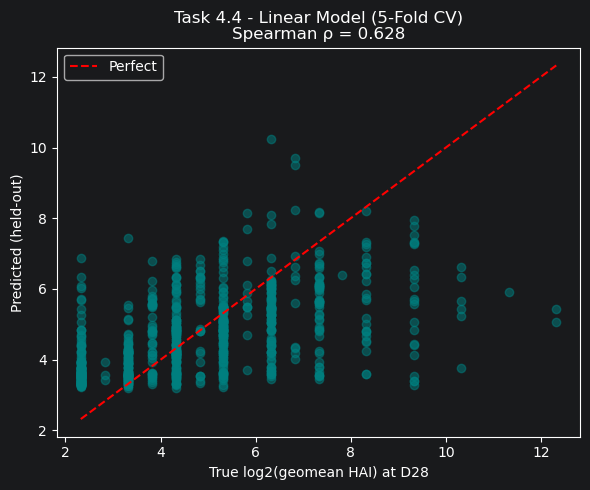

Model saved to models/task_4_4_model.pkl


In [4]:
vaccine_d28_cols = vaccine_cols(data, VACCINE_STRAINS, '28')
vaccine_d0_cols = vaccine_cols(data, VACCINE_STRAINS, '0')

# Target: mean of log2 HAI at D28 across the 3 vaccine strains == log2(geomean on raw scale).
# Require at least one of the 3 strains to be measured; mean skips NaN.
y_vals = data[vaccine_d28_cols].mean(axis=1, skipna=True)
mask = y_vals.notna()
y_vals = y_vals[mask]

feature_cols = vaccine_d0_cols + part_cols
X = data.loc[mask, feature_cols].copy()

y_pred_cv, model = evaluate(X, y_vals, 'Task 4.4', y_axis_label='True log2(geomean HAI) at D28')

os.makedirs('models', exist_ok=True)
joblib.dump(model, MODEL_PATH)
print(f'Model saved to {MODEL_PATH}')

In [5]:
y_pred_challenge = predict_challenge(model, challenge_data, feature_cols)

results = pd.DataFrame({
    'Participant_ID': challenge_data['participant_id'].values,
    'Task_4.4*': np.exp2(y_pred_challenge),  # reverse log2 -> raw titer geomean
})
os.makedirs('submission', exist_ok=True)
results.to_csv(SUBMISSION_PATH, index=False)
results

,Participant_ID,Task_4.4*
0,2024_UGA.ID_077,33.665440
1,2024_UGA.ID_086,52.971010
2,2024_UGA.ID_128,24.093793
3,2024_UGA.ID_170,22.055204
4,2024_UGA.ID_179,51.387502
5,2024_UGA.ID_215,27.905984
6,2024_UGA.ID_219,37.400778
7,2024_UGA.ID_275,37.908066
8,2024_UGA.ID_295,346.167522
9,2024_UGA.ID_296,29.197558
